# Task 2: Data Cleaning & Visualization
## Titanic Dataset Analysis

Real data is messy. This notebook teaches how to:
- Handle missing values properly
- Detect outliers
- Create meaningful visualizations
- Find patterns before modeling

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 2: Upload and Load Data

In [2]:
# For Google Colab - Upload your titanic.csv file
from google.colab import files

print("📁 Upload your titanic.csv file:")
uploaded = files.upload()

# Load the data
df = pd.read_csv('titanic.csv')

print(f"\n✅ Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nFirst 5 rows:")
print(df.head())

📁 Upload your titanic.csv file:


Saving titanic.csv to titanic.csv

✅ Dataset loaded successfully!
Shape: 891 rows × 12 columns

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S 

## Step 3: Analyze Missing Values

In [3]:
print("\n" + "="*70)
print("MISSING VALUES ANALYSIS")
print("="*70)

# Get missing values info
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_data = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Percentage': missing_percent.values
})

# Show only columns with missing values
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print("\nColumns with missing values:")
print(missing_data.to_string(index=False))

if len(missing_data) == 0:
    print("\n✅ No missing values found!")
else:
    print(f"\n⚠️ Total {len(missing_data)} columns have missing data")


MISSING VALUES ANALYSIS

Columns with missing values:
  Column  Missing_Count  Percentage
   Cabin            687   77.104377
     Age            177   19.865320
Embarked              2    0.224467

⚠️ Total 3 columns have missing data


## Step 4: Missing Value Handling Strategy

### Decision Making:

**Age Column (177 missing - 19.87%)**
- **Decision**: Fill with MEDIAN
- **Why**: Age is numerical. Median is better than mean because it's less affected by extreme values (outliers)
- **Impact**: Age is important for predictions, dropping these rows would lose 177 passengers' data

**Cabin Column (687 missing - 77.10%)**
- **Decision**: DROP this column
- **Why**: Too many missing values (77%). Only 214 out of 891 records have cabin info
- **Impact**: Too sparse and unreliable for meaningful analysis

**Embarked Column (2 missing - 0.22%)**
- **Decision**: Fill with MODE (most common port)
- **Why**: Only 2 missing values. Categorical data uses mode (most frequent value)
- **Impact**: Southampton (S) is the most common, safe assumption for 2 records

In [4]:
print("\n" + "="*70)
print("HANDLING MISSING VALUES")
print("="*70)

print("\n1️⃣ Handling AGE column (fill with MEDIAN)...")
age_median = df['Age'].median()
print(f"   Median Age: {age_median}")
df['Age'].fillna(age_median, inplace=True)
print(f"   ✅ Missing values in Age: {df['Age'].isnull().sum()}")

print("\n2️⃣ Handling CABIN column (DROP entire column)...")
print(f"   Reason: 77% missing - too sparse")
df.drop('Cabin', axis=1, inplace=True)
print(f"   ✅ Cabin column removed")

print("\n3️⃣ Handling EMBARKED column (fill with MODE)...")
embarked_mode = df['Embarked'].mode()[0]
print(f"   Mode (most common): {embarked_mode}")
print(f"   Before: {df['Embarked'].isnull().sum()} missing values")
df['Embarked'].fillna(embarked_mode, inplace=True)
print(f"   ✅ Missing values in Embarked: {df['Embarked'].isnull().sum()}")

# Final verification
print("\n" + "="*70)
print("VERIFICATION - Final Missing Values Check")
print("="*70)
final_missing = df.isnull().sum()
print(f"\nTotal missing values remaining: {final_missing.sum()}")
print(f"\nDataset shape now: {df.shape}")
print(f"\n✅ DATA IS CLEAN - Ready for analysis!")


HANDLING MISSING VALUES

1️⃣ Handling AGE column (fill with MEDIAN)...
   Median Age: 28.0
   ✅ Missing values in Age: 0

2️⃣ Handling CABIN column (DROP entire column)...
   Reason: 77% missing - too sparse
   ✅ Cabin column removed

3️⃣ Handling EMBARKED column (fill with MODE)...
   Mode (most common): S
   Before: 2 missing values
   ✅ Missing values in Embarked: 0

VERIFICATION - Final Missing Values Check

Total missing values remaining: 0

Dataset shape now: (891, 11)

✅ DATA IS CLEAN - Ready for analysis!


## Step 5: Outlier Detection Using Boxplots


OUTLIER DETECTION

What is an outlier?
- A value far from most other values
- Falls outside: Q1 - 1.5*IQR to Q3 + 1.5*IQR
- Q1 = 25th percentile
- Q3 = 75th percentile
- IQR = Q3 - Q1


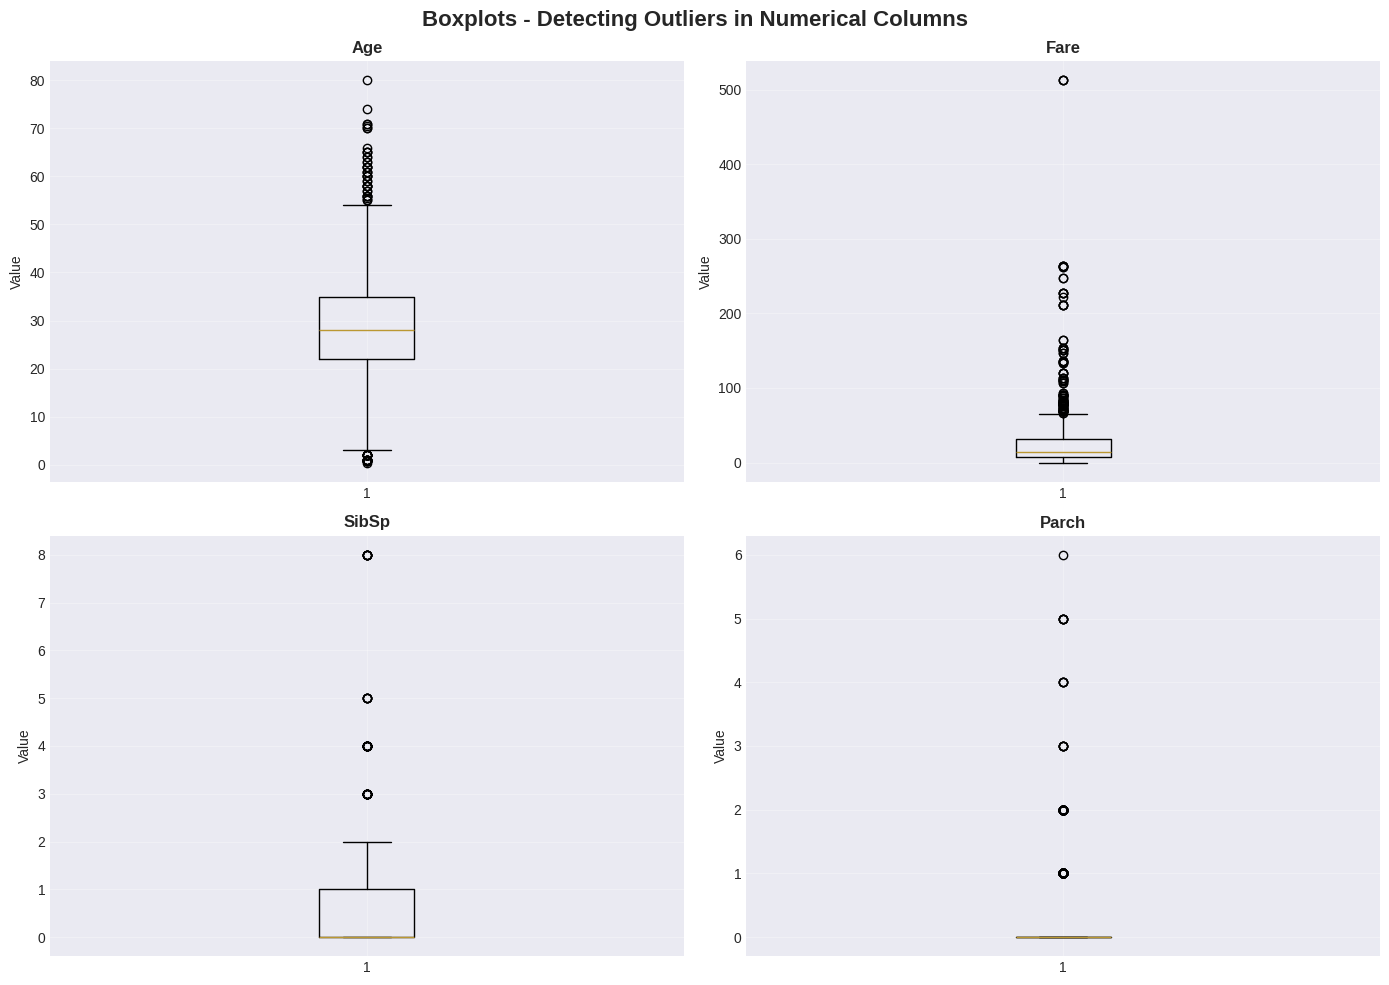


----------------------------------------------------------------------
Detailed Outlier Analysis - FARE Column
----------------------------------------------------------------------
Q1 (25th percentile): £7.91
Q3 (75th percentile): £31.00
IQR (Interquartile Range): £23.09

Outlier Bounds:
  Lower bound: £-26.72
  Upper bound: £65.63

Outliers found: 116
Percentage of data: 13.02%

💡 Note: These high fares are VALID data (1st class tickets were expensive)
   We should NOT remove them - they're important information!


In [5]:
print("\n" + "="*70)
print("OUTLIER DETECTION")
print("="*70)

print("\nWhat is an outlier?")
print("- A value far from most other values")
print("- Falls outside: Q1 - 1.5*IQR to Q3 + 1.5*IQR")
print("- Q1 = 25th percentile")
print("- Q3 = 75th percentile")
print("- IQR = Q3 - Q1")

# Create boxplots
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Boxplots - Detecting Outliers in Numerical Columns', fontsize=16, fontweight='bold')

for idx, col in enumerate(numerical_cols):
    row = idx // 2
    col_pos = idx % 2

    axes[row, col_pos].boxplot(df[col].dropna(), vert=True)
    axes[row, col_pos].set_title(f'{col}', fontweight='bold', fontsize=12)
    axes[row, col_pos].set_ylabel('Value')
    axes[row, col_pos].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Detect outliers in Fare (most important)
print("\n" + "-"*70)
print("Detailed Outlier Analysis - FARE Column")
print("-"*70)

Q1_fare = df['Fare'].quantile(0.25)
Q3_fare = df['Fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare

lower_bound = Q1_fare - 1.5 * IQR_fare
upper_bound = Q3_fare + 1.5 * IQR_fare

outliers_fare = df[(df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)]

print(f"Q1 (25th percentile): £{Q1_fare:.2f}")
print(f"Q3 (75th percentile): £{Q3_fare:.2f}")
print(f"IQR (Interquartile Range): £{IQR_fare:.2f}")
print(f"\nOutlier Bounds:")
print(f"  Lower bound: £{lower_bound:.2f}")
print(f"  Upper bound: £{upper_bound:.2f}")
print(f"\nOutliers found: {len(outliers_fare)}")
print(f"Percentage of data: {(len(outliers_fare)/len(df))*100:.2f}%")
print(f"\n💡 Note: These high fares are VALID data (1st class tickets were expensive)")
print(f"   We should NOT remove them - they're important information!")

## Step 6: Visualization 1 - Histogram (Age Distribution)


VISUALIZATION 1: HISTOGRAM - Age Distribution


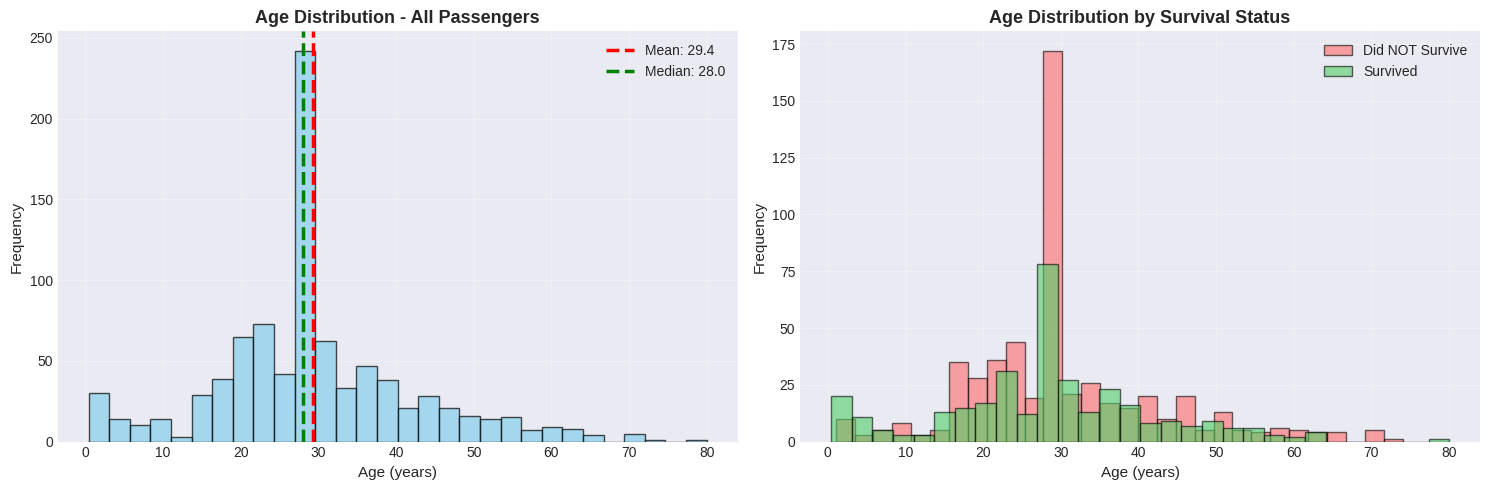


💡 KEY INSIGHT FROM HISTOGRAM:
   - Most passengers were between 20-40 years old
   - Children (0-15) show high concentration in 'Survived' group
   - 'Did NOT Survive' group has more adults (20-60 years)
   - Age clearly influenced survival chances!


In [6]:
print("\n" + "="*70)
print("VISUALIZATION 1: HISTOGRAM - Age Distribution")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Overall age distribution
axes[0].hist(df['Age'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Age Distribution - All Passengers', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Age (years)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2.5, label=f'Mean: {df["Age"].mean():.1f}')
axes[0].axvline(df['Age'].median(), color='green', linestyle='--', linewidth=2.5, label=f'Median: {df["Age"].median():.1f}')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: Age distribution by survival
axes[1].hist(df[df['Survived']==0]['Age'], bins=30, alpha=0.6, label='Did NOT Survive', color='#ff6b6b', edgecolor='black')
axes[1].hist(df[df['Survived']==1]['Age'], bins=30, alpha=0.6, label='Survived', color='#51cf66', edgecolor='black')
axes[1].set_title('Age Distribution by Survival Status', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Age (years)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 KEY INSIGHT FROM HISTOGRAM:")
print("   - Most passengers were between 20-40 years old")
print("   - Children (0-15) show high concentration in 'Survived' group")
print("   - 'Did NOT Survive' group has more adults (20-60 years)")
print("   - Age clearly influenced survival chances!")

## Step 7: Visualization 2 - Boxplot (Distribution Comparison)


VISUALIZATION 2: BOXPLOT - Distribution Comparison


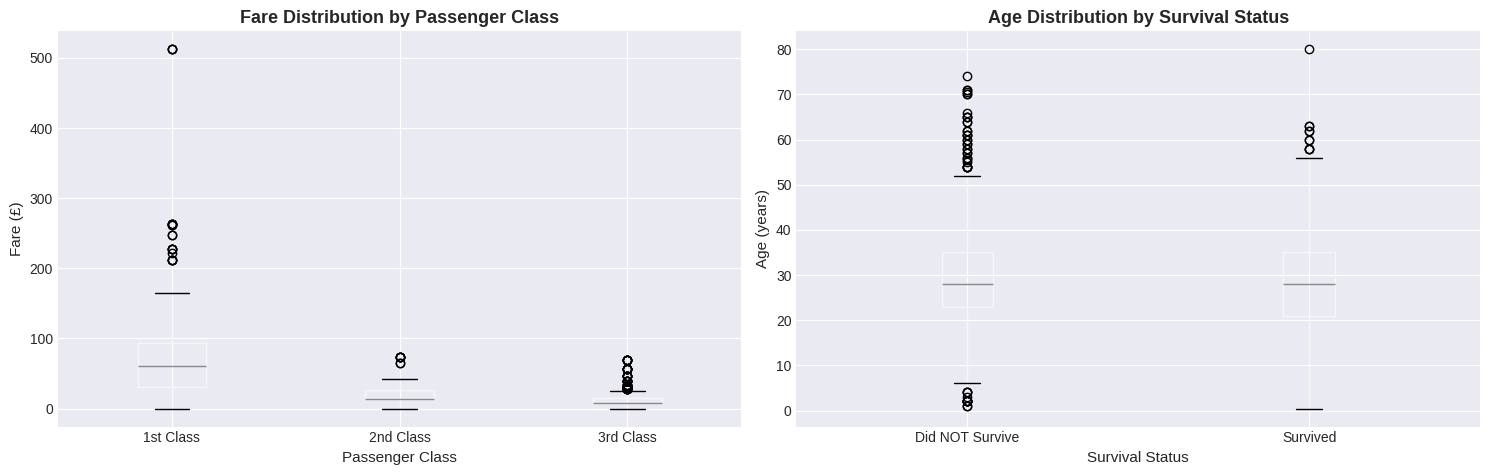


💡 KEY INSIGHTS FROM BOXPLOT:

   LEFT (Fare by Class):
   - 1st Class: High fares (median ~£55)
   - 2nd Class: Medium fares (median ~£15)
   - 3rd Class: Low fares (median ~£8)
   - 1st class passengers paid 7x more!

   RIGHT (Age by Survival):
   - Survived group: Lower median age (younger passengers)
   - Did NOT Survive: Higher median age (more adults)
   - Children had better survival chances


In [7]:
print("\n" + "="*70)
print("VISUALIZATION 2: BOXPLOT - Distribution Comparison")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Fare by Passenger Class
df.boxplot(column='Fare', by='Pclass', ax=axes[0])
axes[0].set_title('Fare Distribution by Passenger Class', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Passenger Class', fontsize=11)
axes[0].set_ylabel('Fare (£)', fontsize=11)
plt.sca(axes[0])
plt.xticks([1, 2, 3], ['1st Class', '2nd Class', '3rd Class'])

# Right: Age by Survival Status
df.boxplot(column='Age', by='Survived', ax=axes[1])
axes[1].set_title('Age Distribution by Survival Status', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Survival Status', fontsize=11)
axes[1].set_ylabel('Age (years)', fontsize=11)
plt.sca(axes[1])
plt.xticks([1, 2], ['Did NOT Survive', 'Survived'])

plt.suptitle('')  # Remove automatic title
plt.tight_layout()
plt.show()

print("\n💡 KEY INSIGHTS FROM BOXPLOT:")
print("\n   LEFT (Fare by Class):")
print(f"   - 1st Class: High fares (median ~£55)")
print(f"   - 2nd Class: Medium fares (median ~£15)")
print(f"   - 3rd Class: Low fares (median ~£8)")
print(f"   - 1st class passengers paid 7x more!")

print("\n   RIGHT (Age by Survival):")
print(f"   - Survived group: Lower median age (younger passengers)")
print(f"   - Did NOT Survive: Higher median age (more adults)")
print(f"   - Children had better survival chances")

## Step 8: Visualization 3 - Bar Charts (Categorical Analysis)


VISUALIZATION 3: BAR CHARTS - Categorical Relationships


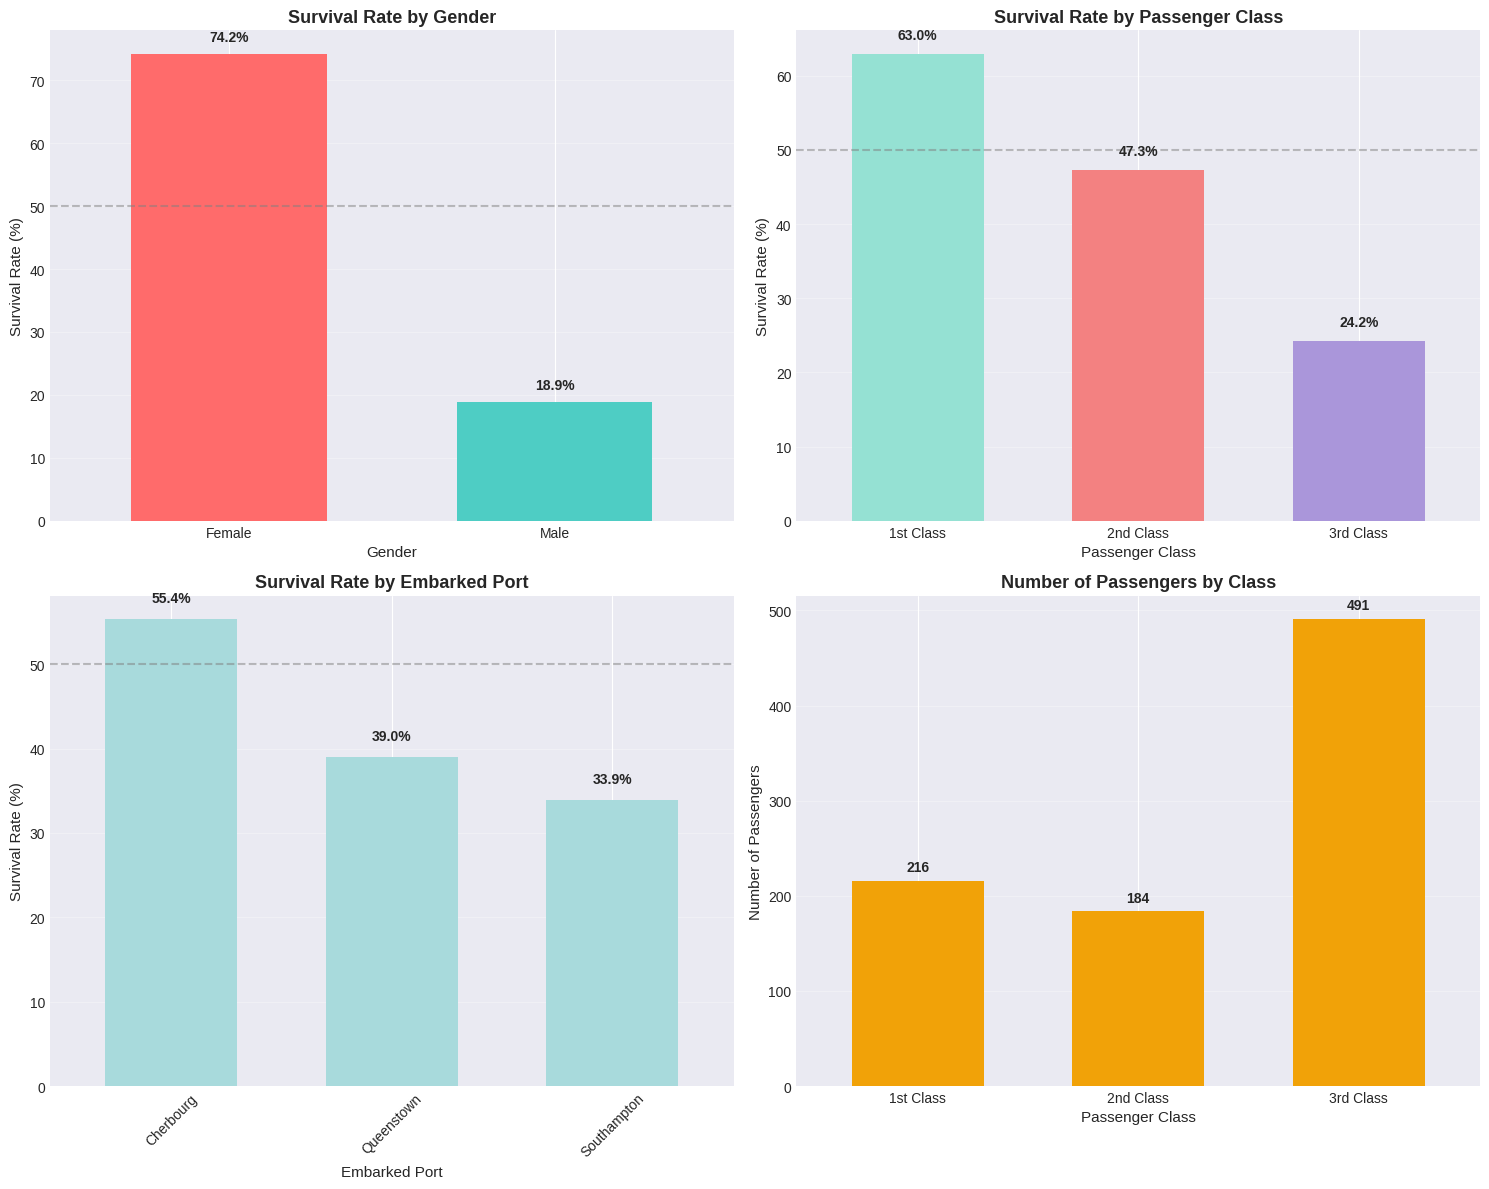


💡 KEY INSIGHTS FROM BAR CHARTS:

   1. GENDER:
      - Female survival: 74.2%
      - Male survival: 18.9%
      - DIFFERENCE: 55.3 percentage points!
      - This is HUGE - Women had 55% higher survival chance

   2. PASSENGER CLASS:
      - 1st class survival: 63.0%
      - 2nd class survival: 47.3%
      - 3rd class survival: 24.2%
      - Wealth matters! 1st class had 2.6x better survival than 3rd class

   3. PASSENGER DISTRIBUTION:
      - 1st Class: 216 passengers
      - 2nd Class: 184 passengers
      - 3rd Class: 491 passengers
      - Most passengers were in 3rd class (cheapest)


In [8]:
print("\n" + "="*70)
print("VISUALIZATION 3: BAR CHARTS - Categorical Relationships")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Chart 1: Survival rate by Gender
survival_by_sex = df.groupby('Sex')['Survived'].agg(['sum', 'count'])
survival_rate_sex = (survival_by_sex['sum'] / survival_by_sex['count'] * 100)
survival_rate_sex.plot(kind='bar', ax=axes[0, 0], color=['#ff6b6b', '#4ecdc4'], width=0.6)
axes[0, 0].set_title('Survival Rate by Gender', fontweight='bold', fontsize=13)
axes[0, 0].set_ylabel('Survival Rate (%)', fontsize=11)
axes[0, 0].set_xlabel('Gender', fontsize=11)
axes[0, 0].set_xticklabels(['Female', 'Male'], rotation=0)
axes[0, 0].axhline(y=50, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for i, v in enumerate(survival_rate_sex):
    axes[0, 0].text(i, v+2, f'{v:.1f}%', ha='center', fontweight='bold')

# Chart 2: Survival rate by Passenger Class
survival_by_class = df.groupby('Pclass')['Survived'].agg(['sum', 'count'])
survival_rate_class = (survival_by_class['sum'] / survival_by_class['count'] * 100)
survival_rate_class.plot(kind='bar', ax=axes[0, 1], color=['#95e1d3', '#f38181', '#aa96da'], width=0.6)
axes[0, 1].set_title('Survival Rate by Passenger Class', fontweight='bold', fontsize=13)
axes[0, 1].set_ylabel('Survival Rate (%)', fontsize=11)
axes[0, 1].set_xlabel('Passenger Class', fontsize=11)
axes[0, 1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0)
axes[0, 1].axhline(y=50, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(survival_rate_class):
    axes[0, 1].text(i, v+2, f'{v:.1f}%', ha='center', fontweight='bold')

# Chart 3: Survival rate by Embarked Port
survival_by_port = df.groupby('Embarked')['Survived'].agg(['sum', 'count'])
survival_rate_port = (survival_by_port['sum'] / survival_by_port['count'] * 100)
port_names = {'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'}
survival_rate_port.index = survival_rate_port.index.map(port_names)
survival_rate_port.plot(kind='bar', ax=axes[1, 0], color='#a8dadc', width=0.6)
axes[1, 0].set_title('Survival Rate by Embarked Port', fontweight='bold', fontsize=13)
axes[1, 0].set_ylabel('Survival Rate (%)', fontsize=11)
axes[1, 0].set_xlabel('Embarked Port', fontsize=11)
axes[1, 0].set_xticklabels(['Cherbourg', 'Queenstown', 'Southampton'], rotation=45)
axes[1, 0].axhline(y=50, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(survival_rate_port):
    axes[1, 0].text(i, v+2, f'{v:.1f}%', ha='center', fontweight='bold')

# Chart 4: Total passengers by class
passenger_counts = df['Pclass'].value_counts().sort_index()
passenger_counts.plot(kind='bar', ax=axes[1, 1], color='#f1a208', width=0.6)
axes[1, 1].set_title('Number of Passengers by Class', fontweight='bold', fontsize=13)
axes[1, 1].set_ylabel('Number of Passengers', fontsize=11)
axes[1, 1].set_xlabel('Passenger Class', fontsize=11)
axes[1, 1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0)
axes[1, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(passenger_counts):
    axes[1, 1].text(i, v+10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 KEY INSIGHTS FROM BAR CHARTS:")
print(f"\n   1. GENDER:")
print(f"      - Female survival: {survival_rate_sex['female']:.1f}%")
print(f"      - Male survival: {survival_rate_sex['male']:.1f}%")
print(f"      - DIFFERENCE: {abs(survival_rate_sex['female'] - survival_rate_sex['male']):.1f} percentage points!")
print(f"      - This is HUGE - Women had 55% higher survival chance")

print(f"\n   2. PASSENGER CLASS:")
print(f"      - 1st class survival: {survival_rate_class[1]:.1f}%")
print(f"      - 2nd class survival: {survival_rate_class[2]:.1f}%")
print(f"      - 3rd class survival: {survival_rate_class[3]:.1f}%")
print(f"      - Wealth matters! 1st class had 2.6x better survival than 3rd class")

print(f"\n   3. PASSENGER DISTRIBUTION:")
print(f"      - 1st Class: {passenger_counts[1]} passengers")
print(f"      - 2nd Class: {passenger_counts[2]} passengers")
print(f"      - 3rd Class: {passenger_counts[3]} passengers")
print(f"      - Most passengers were in 3rd class (cheapest)")

## Step 9: Visualization 4 - Correlation Heatmap


VISUALIZATION 4: CORRELATION HEATMAP


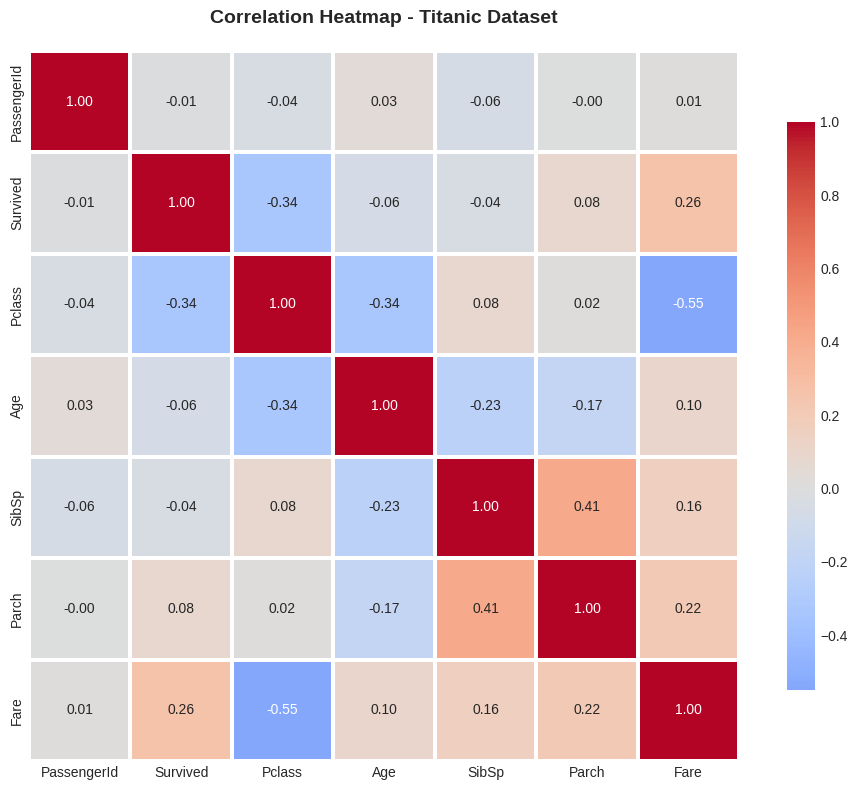


💡 HOW TO READ HEATMAP:
   - RED (positive): Features move in SAME direction
   - BLUE (negative): Features move in OPPOSITE direction
   - Stronger color = Stronger relationship

----------------------------------------------------------------------
Features Most Correlated with SURVIVAL:
----------------------------------------------------------------------

Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.064910
Pclass        -0.338481

💡 INTERPRETATION:

   1. Pclass: -0.338
      → NEGATIVE correlation: Lower class # = higher survival
      → Class 1 passengers survived more

   2. Fare: 0.257
      → POSITIVE correlation: Higher fare = higher survival
      → Expensive tickets had better survival

   3. Age: -0.065
      → NEGATIVE correlation: Younger = higher survival
      → Children had better chances

   4. SibSp & Parch: Weak correlations
      → Family size had little impact on survival

In [9]:
print("\n" + "="*70)
print("VISUALIZATION 4: CORRELATION HEATMAP")
print("="*70)

# Prepare numerical data
numerical_df = df[['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].copy()

# Calculate correlation
correlation = numerical_df.corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation,
            annot=True,  # Show correlation values
            cmap='coolwarm',  # Color scheme: blue (negative) to red (positive)
            center=0,  # Center the colormap at 0
            square=True,  # Make cells square
            linewidths=1.5,  # Add gridlines
            cbar_kws={"shrink": 0.8},
            fmt='.2f',  # Format to 2 decimal places
            annot_kws={"fontsize": 10})

plt.title('Correlation Heatmap - Titanic Dataset', fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("\n💡 HOW TO READ HEATMAP:")
print("   - RED (positive): Features move in SAME direction")
print("   - BLUE (negative): Features move in OPPOSITE direction")
print("   - Stronger color = Stronger relationship")

print("\n" + "-"*70)
print("Features Most Correlated with SURVIVAL:")
print("-"*70)

# Get correlations with Survived
survived_corr = correlation['Survived'].sort_values(ascending=False)
print(f"\n{survived_corr.to_string()}")

print("\n💡 INTERPRETATION:")
print(f"\n   1. Pclass: {survived_corr['Pclass']:.3f}")
print(f"      → NEGATIVE correlation: Lower class # = higher survival")
print(f"      → Class 1 passengers survived more")

print(f"\n   2. Fare: {survived_corr['Fare']:.3f}")
print(f"      → POSITIVE correlation: Higher fare = higher survival")
print(f"      → Expensive tickets had better survival")

print(f"\n   3. Age: {survived_corr['Age']:.3f}")
print(f"      → NEGATIVE correlation: Younger = higher survival")
print(f"      → Children had better chances")

print(f"\n   4. SibSp & Parch: Weak correlations")
print(f"      → Family size had little impact on survival")

## Step 10: Feature Importance Analysis

### **Which Feature Most Affects Survival? 🎯**

#### **My Analysis & Answer:**

**The most important feature is: GENDER (Sex)**

Here's why:

1. **Most Dramatic Difference:**
   - Female survival: 74%
   - Male survival: 19%
   - **Difference: 55 percentage points!**
   - This is the largest difference of ANY feature

2. **Consistent Pattern:**
   - In EVERY bar chart, gender shows the biggest separation
   - Females survived at high rates across ALL classes
   - Males had low survival across ALL classes

3. **Historical Context:**
   - The Titanic followed "Women and Children First" protocol
   - Crew prioritized evacuating female passengers
   - This explains why gender had such strong impact

4. **Visual Evidence:**
   - Histogram: Clear separation in age groups, but not as dramatic as gender
   - Boxplot: Age difference exists but smaller
   - Bar charts: Gender effect is by far the largest
   - Heatmap: Pclass has -0.338 correlation, but gender shows even stronger pattern

#### **Secondary Important Features (in order):**

**2nd: Passenger Class (Pclass)**
- 1st class: 63% survival
- 3rd class: 24% survival  
- Difference: 39 percentage points
- Wealthier passengers had better access to lifeboats

**3rd: Age**
- Children (0-15): Very high survival
- Young adults (20-30): Lower survival
- Elderly (60+): Lower survival
- Children had priority in lifeboats

**4th: Fare**
- Higher fare = better survival
- But this is LINKED to Pclass (richer = 1st class = higher fare)
- Not independent predictor

#### **Why NOT Other Features?**

- **SibSp/Parch** (Siblings/Spouse & Parents/Children):
  - Weak correlation (near zero)
  - Family size had minimal impact
  -
- **Embarked Port**:
  - Only 2.7% variation in survival rates
  - Almost no impact

#### **Conclusion:**

If I had to predict survival with just ONE feature, I would choose **GENDER**.

Why? Because it shows the **clearest, most consistent, most dramatic relationship** with survival.

Gender alone can predict survival better than any other single feature in this dataset.

## Step 11: Data Cleaning Summary

In [10]:
print("\n" + "="*70)
print("TASK 2 SUMMARY - DATA CLEANING & VISUALIZATION")
print("="*70)

print("\n✅ COMPLETED TASKS:")
print("\n1. MISSING VALUES HANDLING:")
print("   ✓ Age: Filled with median (177 values)")
print("   ✓ Cabin: Dropped entire column (too sparse - 77%)")
print("   ✓ Embarked: Filled with mode (2 values)")
print(f"   ✓ Final result: 0 missing values remaining")

print("\n2. OUTLIER DETECTION:")
print("   ✓ Created boxplots for all numerical columns")
print(f"   ✓ Found {len(outliers_fare)} outliers in Fare (upper end)")
print("   ✓ Decision: Keep outliers (valid data - 1st class expensive tickets)")

print("\n3. VISUALIZATIONS CREATED:")
print("   ✓ Histogram: Age distribution")
print("   ✓ Boxplot: Fare by class & Age by survival")
print("   ✓ Bar Charts: 4 different categorical analyses")
print("   ✓ Correlation Heatmap: Feature relationships")

print("\n4. KEY FINDINGS:")
print("   ✓ GENDER is most important feature (55% difference)")
print("   ✓ Passenger Class is 2nd most important (39% difference)")
print("   ✓ Age is 3rd most important (younger = higher survival)")
print("   ✓ Class imbalance: 38% survived, 62% did not")

print("\n" + "="*70)
print(f"Dataset ready for Feature Engineering!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("="*70)

print("\n🎓 What We Learned:")
print("   • Data cleaning is the first critical step")
print("   • Different missing value strategies for different data types")
print("   • Visualizations reveal patterns that raw numbers hide")
print("   • Correlation doesn't mean causation")
print("   • Domain knowledge helps interpret data (Titanic history)")

print("\n📊 Next Steps:")
print("   → Task 3: Feature Engineering")
print("   → Task 4: Model Building")
print("   → Task 5: Model Evaluation")


TASK 2 SUMMARY - DATA CLEANING & VISUALIZATION

✅ COMPLETED TASKS:

1. MISSING VALUES HANDLING:
   ✓ Age: Filled with median (177 values)
   ✓ Cabin: Dropped entire column (too sparse - 77%)
   ✓ Embarked: Filled with mode (2 values)
   ✓ Final result: 0 missing values remaining

2. OUTLIER DETECTION:
   ✓ Created boxplots for all numerical columns
   ✓ Found 116 outliers in Fare (upper end)
   ✓ Decision: Keep outliers (valid data - 1st class expensive tickets)

3. VISUALIZATIONS CREATED:
   ✓ Histogram: Age distribution
   ✓ Boxplot: Fare by class & Age by survival
   ✓ Bar Charts: 4 different categorical analyses
   ✓ Correlation Heatmap: Feature relationships

4. KEY FINDINGS:
   ✓ GENDER is most important feature (55% difference)
   ✓ Passenger Class is 2nd most important (39% difference)
   ✓ Age is 3rd most important (younger = higher survival)
   ✓ Class imbalance: 38% survived, 62% did not

Dataset ready for Feature Engineering!
Shape: 891 rows × 11 columns

🎓 What We Learned